# Para este ejercicio es necesario recordar la forma en que se debe evaluar un prompt. 
La siguiente imagen es tomada del curso oficial:
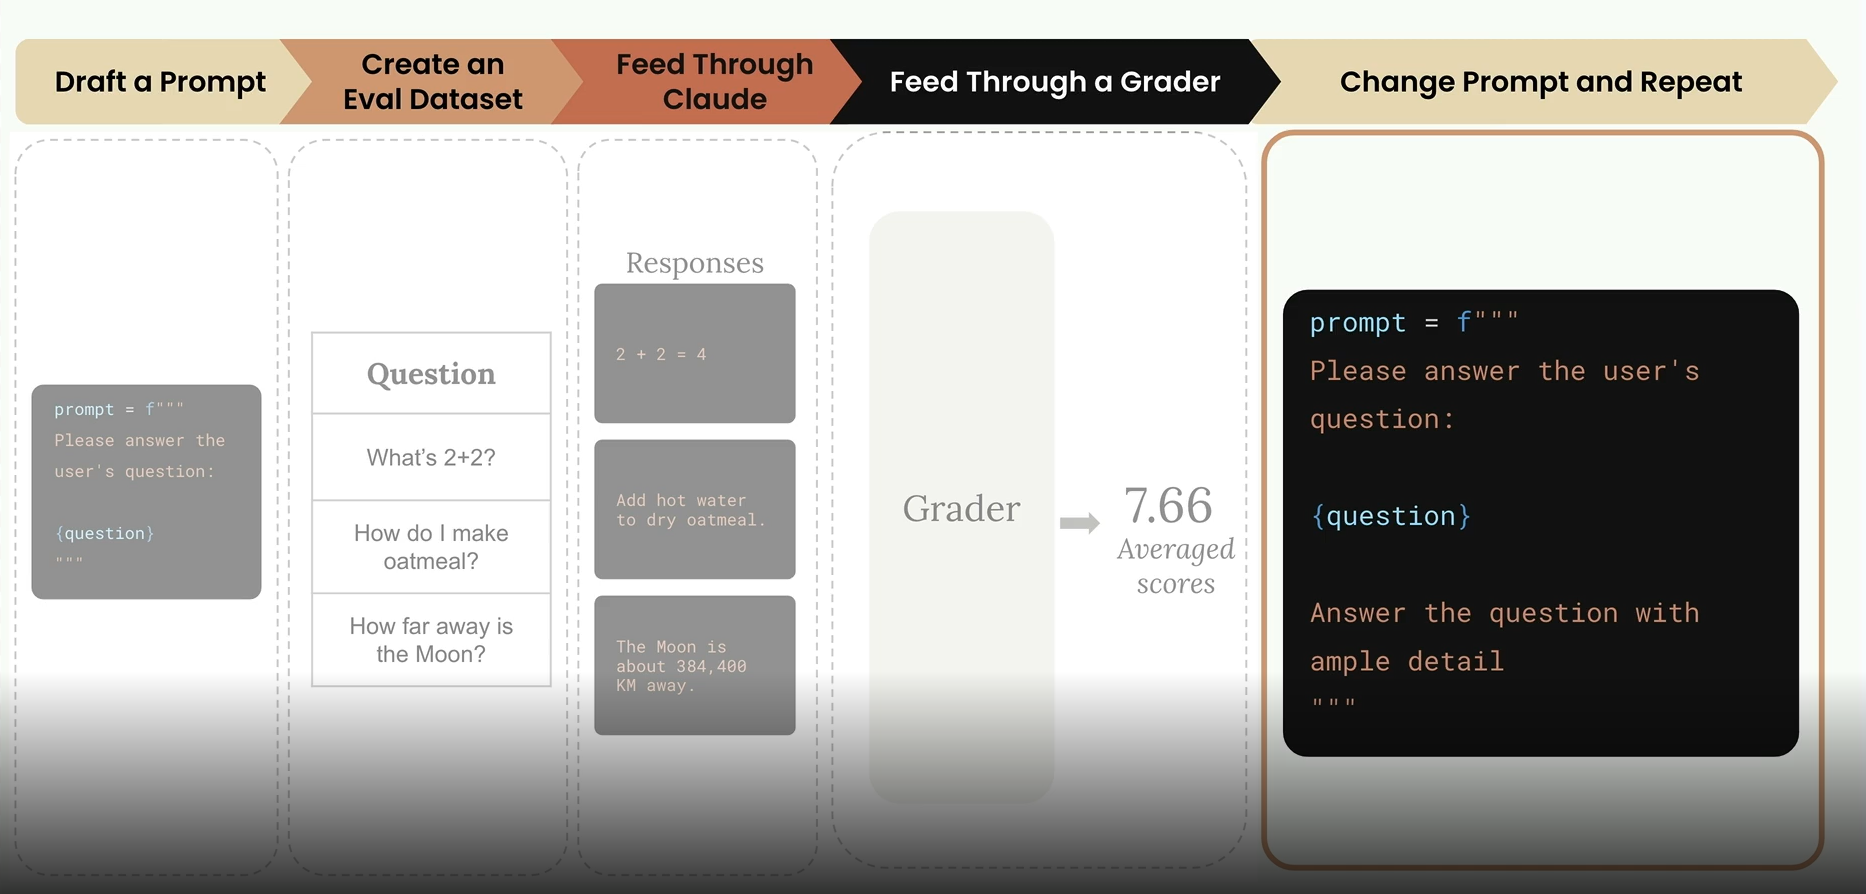

# El objetivo será:
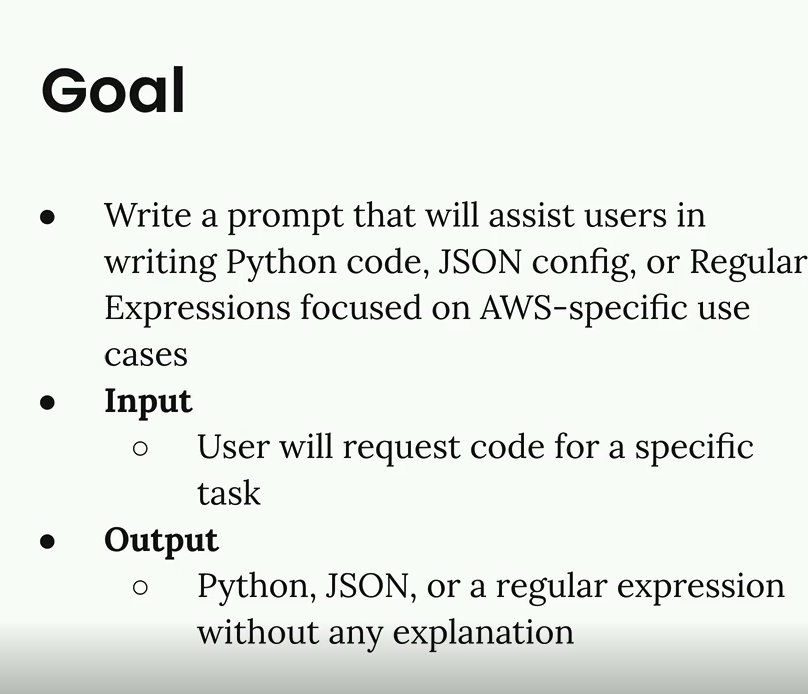



# Iniciamos por diseñar el prompt inicial (prompt V1):

prompt = f"""
Please provide a solution to the following task:

{task}

Respond with only the code (Python, JSON, or Regular Expression) with no explanations, comments, or markdown formatting.
"""

# Segundo paso será armar el dataset de evaluación del prompt V1:
test_dataset = [
    # Python tasks
    {"task": "Write a Python script to list all S3 buckets in my AWS account"},
    {"task": "Write a Python function to upload a file to an S3 bucket"},
    {"task": "Write a Python script to start an EC2 instance by instance ID"},
    {"task": "Write a Python function to get all running EC2 instances"},
    {"task": "Write a Python script to send a message to an SQS queue"},
    
    # JSON tasks
    {"task": "Write a JSON IAM policy that allows read-only access to S3"},
    {"task": "Write a JSON CloudFormation resource to create an S3 bucket"},
    {"task": "Write a JSON EventBridge rule to trigger a Lambda every 5 minutes"},
    {"task": "Write a JSON IAM policy that allows Lambda to write to DynamoDB"},
    {"task": "Write a JSON API Gateway resource definition for a GET endpoint"},
    
    # Regex tasks
    {"task": "Write a regular expression to validate an AWS S3 bucket name"},
    {"task": "Write a regular expression to match an AWS ARN"},
    {"task": "Write a regular expression to validate an AWS region name"},
    {"task": "Write a regular expression to match an EC2 instance ID"},
    {"task": "Write a regular expression to validate an AWS account ID"},
]

In [52]:
# Install dependencies
%pip install anthropic python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
# Load Variables
from dotenv import load_dotenv

load_dotenv()

True

In [54]:
# Create an API Client
from anthropic import Anthropic
import os

client = Anthropic()
model = "claude-sonnet-4-5"

In [55]:
# Funciones auxiliares
from os import system

def add_user_message(messages, user_input):
    messages.append({"role": "user", "content": user_input})

def add_assistant_message(messages, answer):
    messages.append({"role": "assistant", "content": answer})

def chat(messages, system=None, temperature=1.0, stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature
    }
    if system:
        params["system"] = system
    if stop_sequences:
        params["stop_sequences"] = stop_sequences

    response = client.messages.create(**params)
    return response.content[0].text

In [56]:
# Generar dataset
import json

def generate_dataset():
    prompt = """
Generate an evaluation dataset for a prompt evaluation. The dataset will be used to evaluate prompts that generate Python, JSON, or Regex specifically for AWS-related tasks. Generate an array of JSON objects, each representing task that requires Python, JSON, or a Regex to complete.

Example output:
```json
[
{
    "task": "Description of task",
    "format": "JSON" or "Python" or "Regex"
},
...additional
]
```

* Focus on tasks that can be solved by writing a single Python function, a single JSON object, or a single regex
* Focus on tasks that do not require writing much code

Please generate 3 objects.
"""

    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```json")
    text=chat(messages, temperature=0.7, stop_sequences=["```"])
    return json.loads(text)

In [57]:
dataset = generate_dataset()
with open("dataset.json", "w") as f:
    json.dump(dataset, f, indent=2)
#Imprimir el dataset generado si quiero verlo
# print(json.dumps(dataset, indent=2))

In [58]:
#Toma cada uno de los task que estan en el dataset.json (son los test cases)
def run_prompt(test_case):
     """Merges the prompt and test case input, the reutrns the results"""
     prompt=f"""
Please solve the following task: 

{test_case['task']}

*Respond only with the {test_case['format']} without any explanation or additional text.*
"""
     messages = []
     add_user_message(messages, prompt)
     add_assistant_message(messages, "```code")  
     answer=chat(messages, stop_sequences=["```"], temperature=0.7)
     return answer

Ahora procedemos a evaluar con el grader la calidad de las respuestas.

Los graders pueden ser de 3 tipos, code, model y human. En este caso utilizaremos los dos primeros

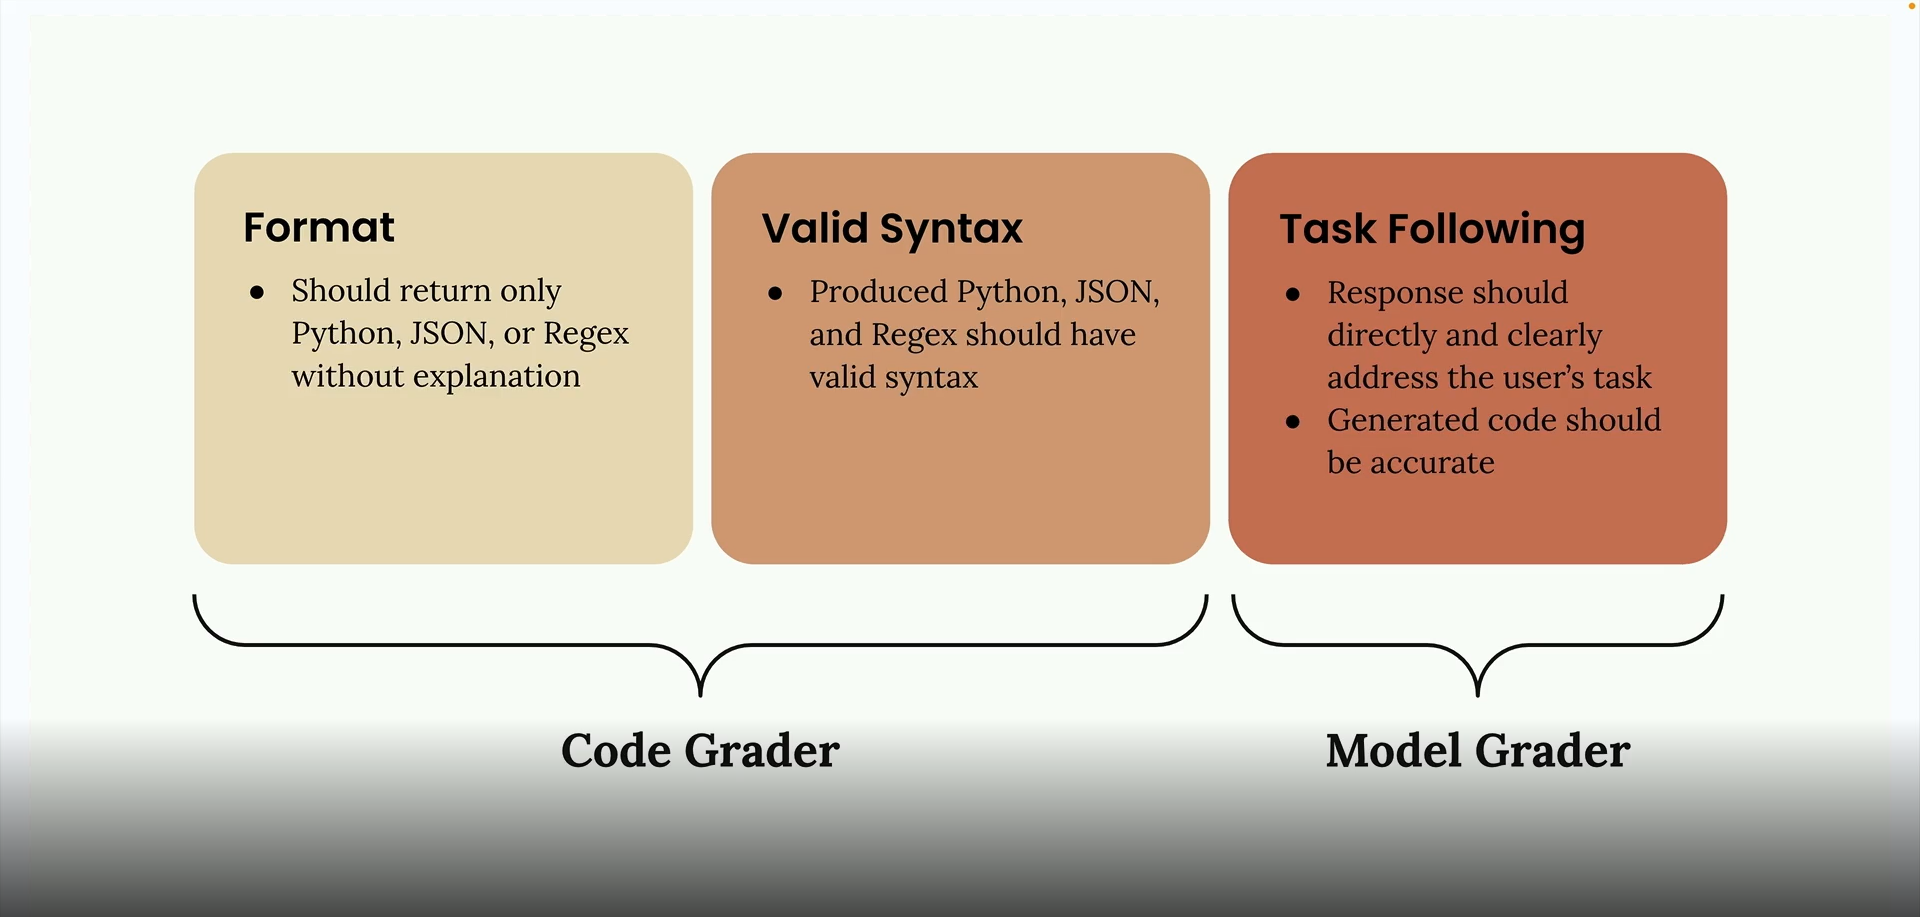

In [59]:
def grade_by_model(test_case, answer):
    # Create evaluation prompt
    eval_prompt = f"""
    You are an expert AWS code reviewer. Your task is to evaluate the following AI-generated solution.
    
    Original Task:
    <task>
    {test_case["task"]}
    </task>

    Solution to Evaluate:
    <solution>
    {answer}
    </solution>
   
    Output Format:
    Provide your evaluation as a structured JSON object with the following fields:
    - "strengths": An array of 1-3 key strengths
    - "weaknesses": An array of 1-3 key areas for improvement  
    - "reasoning": A concise explanation of your assessment
    - "score": A number between 1-10
   
    Respond with JSON. Keep your response concise and direct.
    Example response shape:
    {{
    "strengths": string [],
    "weaknesses": string [], 
    "reasoning": string,
    "score": number
    }}
    """
    
    messages = []
    add_user_message(messages, eval_prompt)
    add_assistant_message(messages, "```json")
    
    eval_text = chat(messages, stop_sequences=["```"])
    return json.loads(eval_text)

In [60]:

import ast
import re

def validate_json(text):
    try:
        json.loads(text.strip())
        return 10
    except json.JSONDecodeError:
        return 0

def validate_python(text):
    try:
        ast.parse(text.strip())
        return 10
    except SyntaxError:
        return 0

def validate_regex(text):
    try:
        re.compile(text.strip())
        return 10
    except re.error:
        return 0
    
def grade_syntax(response, test_case):
    format=test_case["format"]
    if format=="JSON":
        return validate_json(response)
    elif format=="Python":
        return validate_python(response)
    elif format=="Regex":
        return validate_regex(response)
    else:
        raise ValueError(f"Unknown format: {format}")

In [ ]:
#
def run_test_case(test_case):
    """Calls run_prompt, the grades the results"""
    answer=run_prompt(test_case)

    #Grading prompt para evaluar la respuesta y asignarle una calificacion
    model_grade=grade_by_model(test_case, answer)
    model_score=model_grade["score"]
    reasoning =model_grade["reasoning"]
    
    syntax_score=grade_syntax(answer, test_case)
    score=(model_score + syntax_score) / 2
 
    return {
        "answer": answer,
        "test_case": test_case,
        "score": score,
        "reasoning": reasoning
    }

In [62]:
from statistics import mean

def run_eval(dataset):
    """Loads the dataset and calls run_test_case with each test case""" 
    results = []
    for test_case in dataset:
        result = run_test_case(test_case)
        results.append(result)

    average_score = mean(result["score"] for result in results)
    print(f"Average Score: {average_score}")
    return results

In [63]:
with open("dataset.json", "r") as f:
    dataset = json.load(f)

results = run_eval(dataset)

Average Score: 8.5


In [64]:
print(json.dumps(results, indent=2))

[
  {
    "answer": "\n^(?!.*\\.\\.)(?!.*\\.\\-)(?!.*\\-\\.)[a-z0-9][a-z0-9.-]{1,61}[a-z0-9]$\n",
    "test_case": {
      "task": "Write a regex pattern that validates an AWS S3 bucket name according to AWS naming rules: 3-63 characters long, only lowercase letters, numbers, hyphens, and periods, must start and end with a letter or number, and cannot have consecutive periods or period adjacent to hyphen.",
      "format": "Regex"
    },
    "score": 8.5,
    "reasoning": "The regex correctly implements the core naming rules: length constraints, character restrictions, and preventing problematic character combinations. However, it misses several AWS-specific restrictions that are part of the complete S3 bucket naming specification. The pattern would accept some technically invalid bucket names like IP addresses or reserved prefixes/suffixes. For basic validation it works well, but falls short of comprehensive AWS S3 compliance."
  },
  {
    "answer": "\n{\n  \"Version\": \"2012-10-17\